In [44]:
%run general_functions.ipynb

In [52]:
vars = {
    'ALK': {'var_name': 'ALK', 'long': 'Alkalinity', 'unit': r'μ mol $\mathregular{kg^{-1}}$'},
    'DIC': {'var_name': 'DIC', 'long': 'Dissolved Inorganic Carbon', 'unit': r'μ mol $\mathregular{kg^{-1}}$'},
    'mld': {'var_name': 'somxl010', 'long': 'Mixed Layer Depth', 'unit': r'm'},
}

scenarios = {'126':'SSP1-2.6','370':'SSP3-7.0'}
sims = {'baseline':'Baseline','oae':'OAE'}

weights = (grid_cell_ocean.sel(x=slice(520, 595), y=slice(330, 435))).fillna(0)

alk_mask = xr.open_dataset(data_path + '../alk_mask/alkalinity_mask_timeseries.nc')['alk_flux'].sum('time_counter')
alk_mask = alk_mask.where(alk_mask)
alk_mask = (alk_mask.sel(x=slice(520, 595), y=slice(330, 435))).fillna(0)

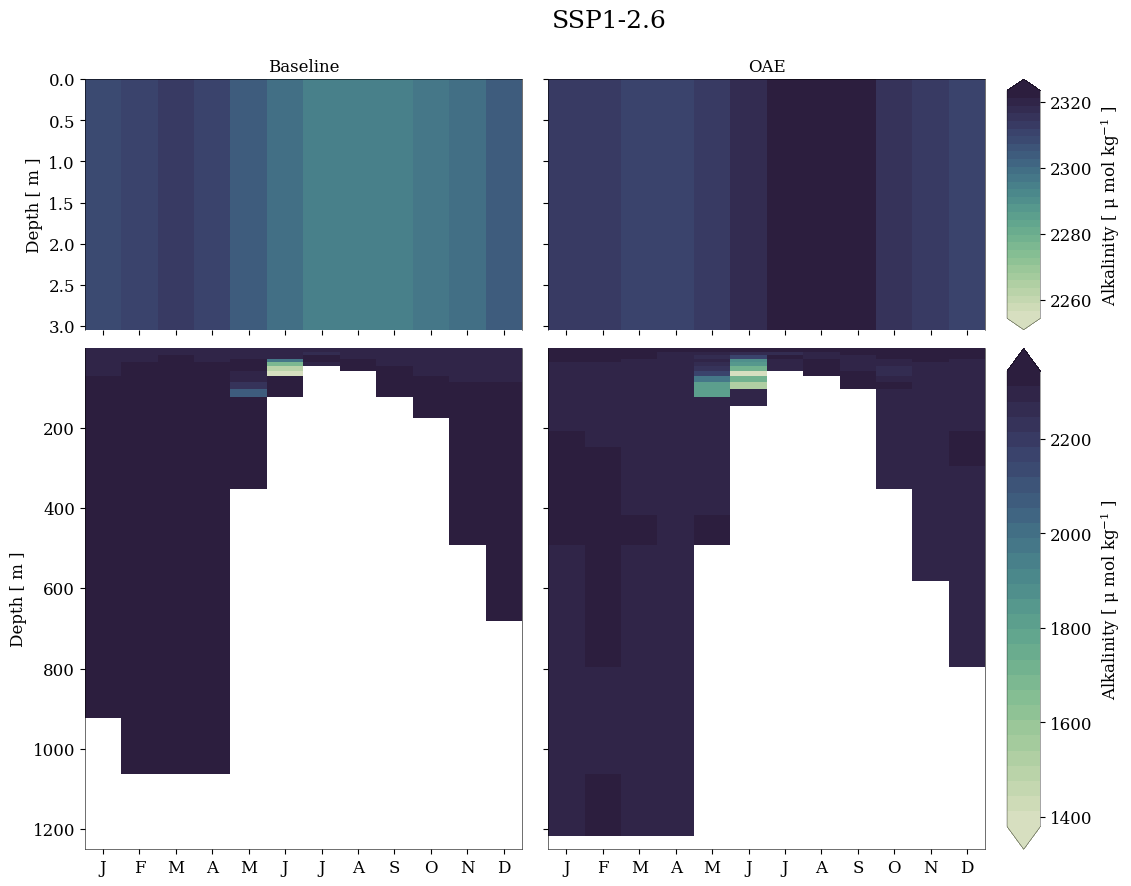

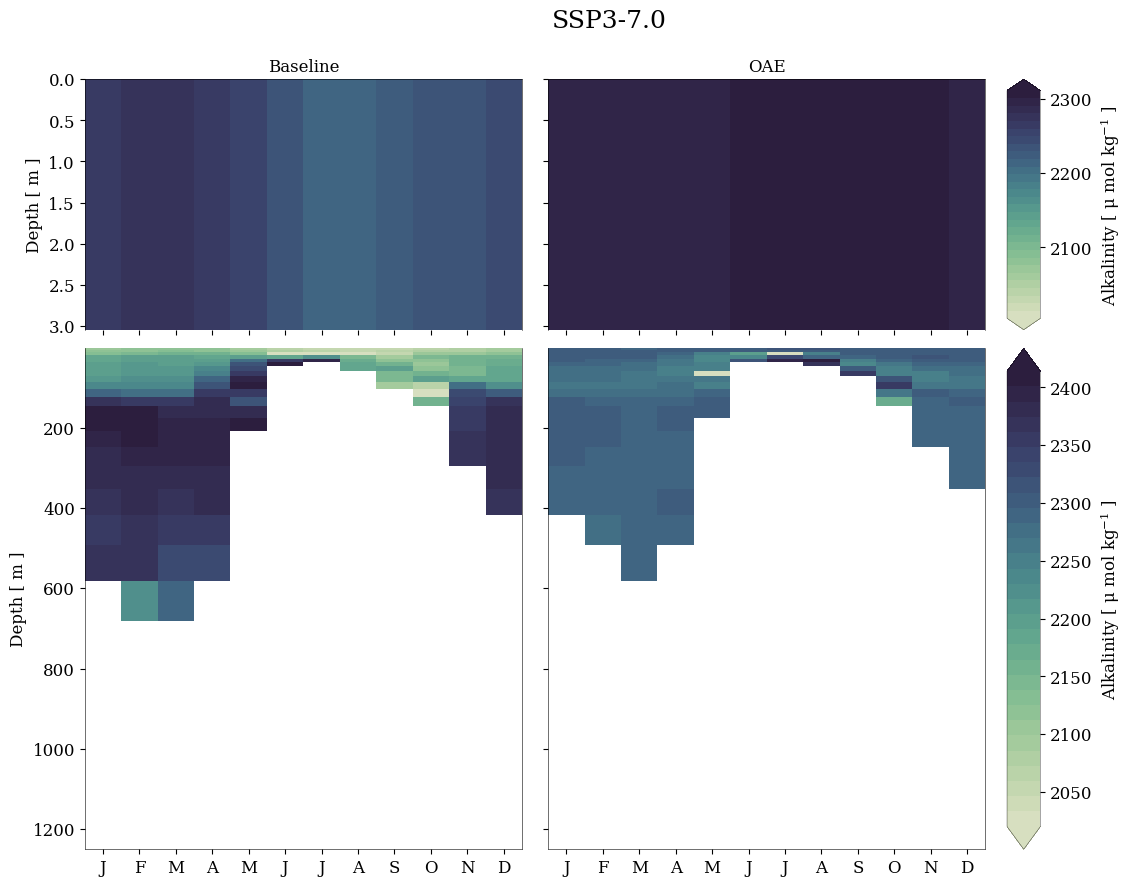

In [75]:
# COASTLINE AVERAGE

for scen, scen_name in scenarios.items():

    fig, axes = plt.subplots(
        2, 2,
        sharex=True,
        figsize=(14,10),
        gridspec_kw={'height_ratios':[1,2], 'hspace':0.05, 'wspace':0.06}
    )

    for col, (sim, sim_name) in enumerate(sims.items()):

        ax_top = axes[0, col]
        ax_bot = axes[1, col]

        cmap = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)
        cmap, norm = create_discrete_cmap(cmap, 30)
    
        # ---- Load datasets
        mld = xr.open_dataset(f"{data_path}mld_{sim}_{scen}.nc")

        var = 'ALK'
        alkalinity = xr.open_dataset(f"{data_path}{var}_{sim}_{scen}.nc")
        unit = alkalinity[var].units
        alkalinity = alkalinity.where(alkalinity['deptht'] < mld['somxl010'])
        
        weighted = alkalinity.weighted(weights).mean(('x','y'))
        final = seasonal_avg(weighted, var)

        vmin_top = float(final[var].sel(deptht=slice(0,20)).min())
        vmax_top = float(final[var].sel(deptht=slice(0,20)).max())
        # ---- Plot
        im_top = final[var].T.plot(
            ax=ax_top,
            vmin=vmin_top,
            vmax=vmax_top,
            cmap=cmap,
            add_colorbar=False
        )
        # cb_top = fig.colorbar(im_top, ax=ax_top, extend='both', aspect=10, location='right')
        
        vmin_bot = float(final[var].sel(deptht=slice(20,None)).min())
        vmax_bot = float(final[var].sel(deptht=slice(20,None)).max())
        
        im_bot = final[var].T.plot(
            ax=ax_bot,
            vmin=vmin_bot,
            vmax=vmax_bot,
            cmap=cmap,
            add_colorbar=False
        )
        # ---- Broken axis limits
        first_level = final['deptht'][0]
        ax_top.set_ylim(first_level,0)
        ax_bot.set_ylim(1250,first_level)

        # ---- Hide connecting spines
        ax_top.spines['bottom'].set_visible(False)
        ax_bot.spines['top'].set_visible(False)

        ax_top.set_title(sim_name)

        # ---- Break marks
        d = .3
        kwargs = dict(marker=[(-1,-d),(1,d)], markersize=12,
                      linestyle="none", color='k', mec='k', mew=1, clip_on=False)

        month_label = ['J','F','M','A','M','J','J','A','S','O','N','D']

        for ax in [ax_top,ax_bot]:
            ax.set_xticks(np.arange(1, 13, 1))
            ax.set_xticklabels(month_label, fontsize=16)

            ax.set_ylabel('Depth [ m ]')
            ax.set_xlabel('')

            map_outlook(ax,12)

        if col == 1:
            for ax in [ax_top, ax_bot]:
                ax.set_ylabel('')
                ax.tick_params(axis='y', labelleft=False)
            
    cb_top = fig.colorbar(im_top, ax=axes[0,:], extend='both', location='right', aspect=7.5, pad=0.02)
    cb_bot = fig.colorbar(im_bot, ax=axes[1,:], extend='both', location='right', aspect=15, pad=0.02)

    for cb in [cb_top, cb_bot]:
        for label in (cb.ax.get_xticklabels() + cb.ax.get_yticklabels() + [cb.ax.title, cb.ax.xaxis.label, cb.ax.yaxis.label]):
            label.set_fontproperties(font_prop)
            label.set_fontsize(12)
        cb.outline.set_linewidth(0.25)
        
        cb.set_label(f'{vars[var]["long"]} [ {vars[var]["unit"]} ]')
    
    fig.suptitle(f"{scen_name}", y=0.95)
    plt.savefig(f'/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure_alk_mld_{scen}_europe.png')

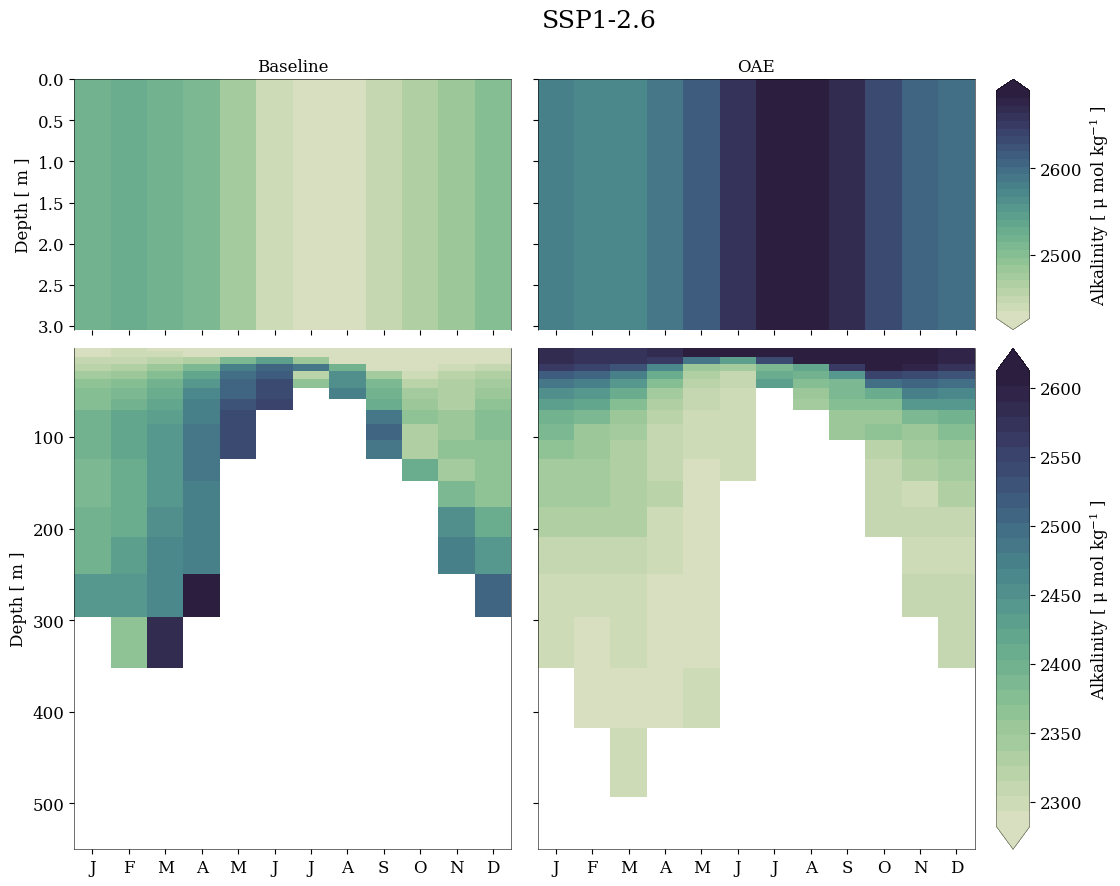

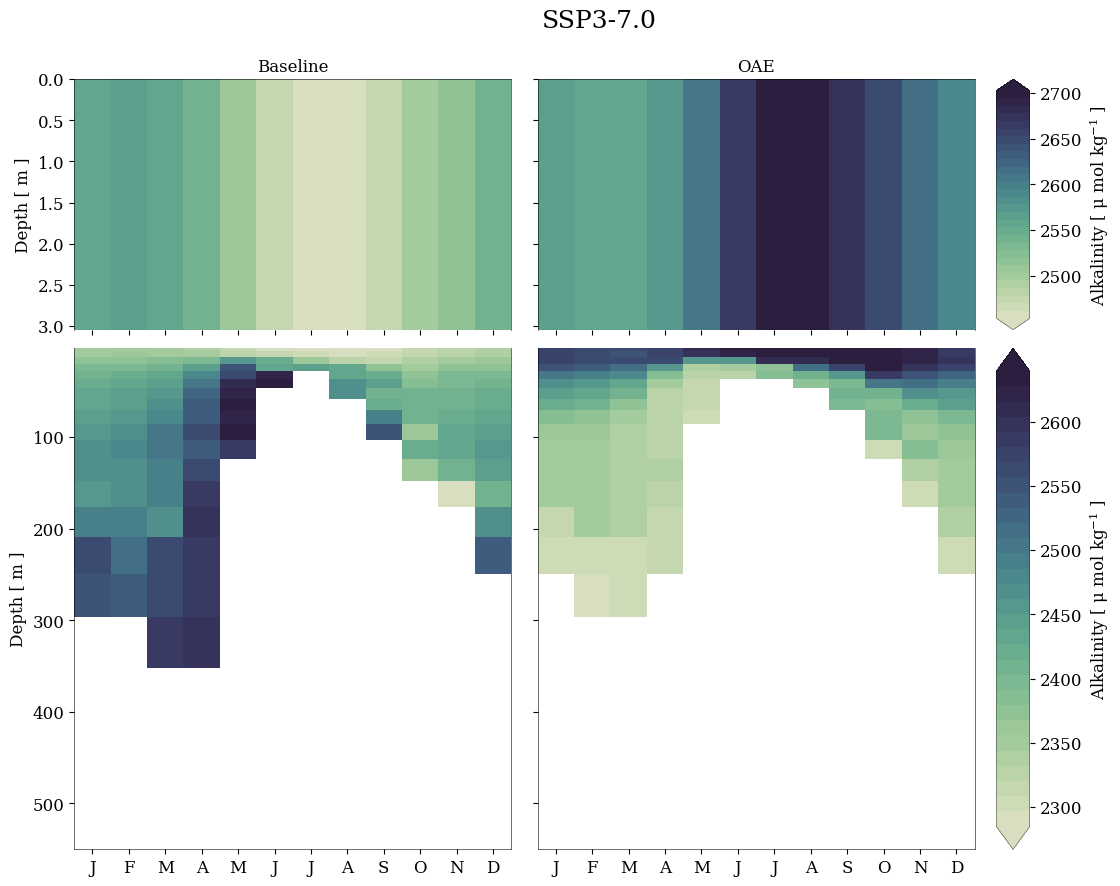

In [76]:
# COASTLINE AVERAGE

for scen, scen_name in scenarios.items():

    fig, axes = plt.subplots(
        2, 2,
        sharex=True,
        figsize=(14,10),
        gridspec_kw={'height_ratios':[1,2], 'hspace':0.05, 'wspace':0.06}
    )

    for col, (sim, sim_name) in enumerate(sims.items()):

        ax_top = axes[0, col]
        ax_bot = axes[1, col]

        cmap = sns.cubehelix_palette(start=.5, rot=-.75, as_cmap=True)
        cmap, norm = create_discrete_cmap(cmap, 30)
    
        # ---- Load datasets
        mld = xr.open_dataset(f"{data_path}mld_{sim}_{scen}.nc")

        var = 'ALK'
        alkalinity = xr.open_dataset(f"{data_path}{var}_{sim}_{scen}.nc")
        unit = alkalinity[var].units
        alkalinity = alkalinity.where(alkalinity['deptht'] < mld['somxl010'])

        # COASTLINE MASK ---------------------
        alkalinity = alkalinity.where(alk_mask)
        # COASTLINE MASK ---------------------
        
        weighted = alkalinity.weighted(weights).mean(('x','y'))
        final = seasonal_avg(weighted, var)

        vmin_top = float(final[var].sel(deptht=slice(0,20)).min())
        vmax_top = float(final[var].sel(deptht=slice(0,20)).max())
        # ---- Plot
        im_top = final[var].T.plot(
            ax=ax_top,
            vmin=vmin_top,
            vmax=vmax_top,
            cmap=cmap,
            add_colorbar=False
        )
        # cb_top = fig.colorbar(im_top, ax=ax_top, extend='both', aspect=10, location='right')
        
        vmin_bot = float(final[var].sel(deptht=slice(20,None)).min())
        vmax_bot = float(final[var].sel(deptht=slice(20,None)).max())
        
        im_bot = final[var].T.plot(
            ax=ax_bot,
            vmin=vmin_bot,
            vmax=vmax_bot,
            cmap=cmap,
            add_colorbar=False
        )
        # ---- Broken axis limits
        first_level = final['deptht'][0]
        ax_top.set_ylim(first_level,0)
        ax_bot.set_ylim(550,first_level)

        # ---- Hide connecting spines
        ax_top.spines['bottom'].set_visible(False)
        ax_bot.spines['top'].set_visible(False)

        ax_top.set_title(sim_name)

        # ---- Break marks
        d = .3
        kwargs = dict(marker=[(-1,-d),(1,d)], markersize=12,
                      linestyle="none", color='k', mec='k', mew=1, clip_on=False)

        month_label = ['J','F','M','A','M','J','J','A','S','O','N','D']

        for ax in [ax_top,ax_bot]:
            ax.set_xticks(np.arange(1, 13, 1))
            ax.set_xticklabels(month_label, fontsize=16)

            ax.set_ylabel('Depth [ m ]')
            ax.set_xlabel('')

            map_outlook(ax,12)

        if col == 1:
            for ax in [ax_top, ax_bot]:
                ax.set_ylabel('')
                ax.tick_params(axis='y', labelleft=False)
            
    cb_top = fig.colorbar(im_top, ax=axes[0,:], extend='both', location='right', aspect=7.5, pad=0.02)
    cb_bot = fig.colorbar(im_bot, ax=axes[1,:], extend='both', location='right', aspect=15, pad=0.02)

    for cb in [cb_top, cb_bot]:
        for label in (cb.ax.get_xticklabels() + cb.ax.get_yticklabels() + [cb.ax.title, cb.ax.xaxis.label, cb.ax.yaxis.label]):
            label.set_fontproperties(font_prop)
            label.set_fontsize(12)
        cb.outline.set_linewidth(0.25)
        
        cb.set_label(f'{vars[var]["long"]} [ {vars[var]["unit"]} ]')
    
    fig.suptitle(f"{scen_name}", y=0.95)
    plt.savefig(f'/Users/chiaraciscato/Desktop/GEOMAR/2025_ciscato_oae_seasonality/out/figure_alk_mld_{scen}_coastline.png')